# Static image rendering (Swing & JavaFX)

This exercises PR #123: `display(component)` / `display(node)` — and a bare last-expression value —
render a GUI component to a **still PNG**. No JupyterLab extension, no comms; the image shows in any
frontend and on GitHub/nbviewer.

- **Swing/AWT** is headless-native (no display needed).
- **JavaFX** is optional (pull it with `%maven`) and needs a display to snapshot — on a headless host run
  the kernel under **Xvfb** (`xvfb-run -a jupyter lab`). Build FX nodes on the JavaFX thread (helper below).

Rebuild the kernel from the `static-image-rendering` branch and reinstall the kernelspec before running.

## Swing / AWT

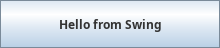

d1df19a6-9b08-42a7-86fd-5559d87814a0

In [1]:
import javax.swing.*;
import java.awt.*;

// A laid-out Swing component renders as a static image.
JButton button = new JButton("Hello from Swing");
button.setSize(220, 48);
display(button);

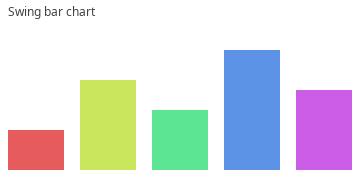

3428dfbe-5159-4364-bd28-aafe00e93858

In [2]:
import javax.swing.*;
import java.awt.*;

// Custom painting also works - here a tiny bar chart.
JPanel chart = new JPanel() {
    protected void paintComponent(Graphics g) {
        super.paintComponent(g);
        Graphics2D g2 = (Graphics2D) g;
        g2.setRenderingHint(RenderingHints.KEY_ANTIALIASING, RenderingHints.VALUE_ANTIALIAS_ON);
        int[] vals = {40, 90, 60, 120, 80};
        int w = getWidth() / vals.length;
        for (int i = 0; i < vals.length; i++) {
            g2.setColor(Color.getHSBColor(i / (float) vals.length, 0.6f, 0.9f));
            g2.fillRect(i * w + 8, getHeight() - vals[i] - 10, w - 16, vals[i]);
        }
        g2.setColor(Color.DARK_GRAY);
        g2.drawString("Swing bar chart", 8, 16);
    }
};
chart.setBackground(Color.WHITE);
chart.setSize(360, 180);
display(chart);

## JavaFX (optional)

Pull OpenJFX (edit the classifier for your OS: `linux` | `mac` | `mac-aarch64` | `win`). JavaFX needs a
display; on a headless host run the kernel under Xvfb. The `fx(...)` helper builds a node on the JavaFX
Application Thread, which is the correct place to construct scene-graph objects.

In [5]:
%maven org.openjfx:javafx-base:jar:linux:21.0.2
%maven org.openjfx:javafx-graphics:jar:linux:21.0.2
%maven org.openjfx:javafx-controls:jar:linux:21.0.2
%maven org.openjfx:javafx-swing:jar:linux:21.0.2

import javafx.application.Platform;
import java.util.concurrent.CountDownLatch;
import java.util.function.Supplier;

// Boots the JavaFX toolkit (needs a display / Xvfb).
new javafx.embed.swing.JFXPanel();

// Build a JavaFX node on the FX thread and return it.
<T> T fx(Supplier<T> builder) throws Exception {
    Object[] holder = new Object[1];
    CountDownLatch latch = new CountDownLatch(1);
    Platform.runLater(() -> { try { holder[0] = builder.get(); } finally { latch.countDown(); } });
    latch.await();
    return (T) holder[0];
}
System.out.println("JavaFX " + System.getProperty("javafx.runtime.version") + " ready");

JavaFX 21.0.2+5 ready


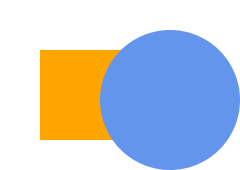

13ca5010-69c2-41e6-8a42-ed5f850e0c56

In [6]:
import javafx.scene.layout.Pane;
import javafx.scene.shape.Circle;
import javafx.scene.shape.Rectangle;
import javafx.scene.paint.Color;

var pane = fx(() -> {
    Pane p = new Pane();
    p.setPrefSize(300, 200);
    Rectangle r = new Rectangle(40, 50, 90, 90);
    r.setFill(Color.ORANGE);
    Circle c = new Circle(170, 100, 70, Color.CORNFLOWERBLUE);
    p.getChildren().addAll(r, c);
    return p;
});
display(pane);

In [7]:
import javafx.scene.chart.BarChart;
import javafx.scene.chart.CategoryAxis;
import javafx.scene.chart.NumberAxis;
import javafx.scene.chart.XYChart;

var chart = fx(() -> {
    BarChart<String, Number> bc = new BarChart<>(new CategoryAxis(), new NumberAxis());
    bc.setTitle("JavaFX BarChart");
    XYChart.Series<String, Number> s = new XYChart.Series<>();
    s.setName("demo");
    s.getData().add(new XYChart.Data<>("A", 40));
    s.getData().add(new XYChart.Data<>("B", 90));
    s.getData().add(new XYChart.Data<>("C", 60));
    bc.getData().add(s);
    bc.setPrefSize(440, 300);
    return bc;
});
display(chart);

453e94d8-1358-46bf-91dc-be209de20e9a